In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

2026-10-10 16:53:56.774726: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
dataset = pd.read_csv("Iris.csv")

In [3]:
print(dataset.info())
print(f"Number of Nulls: \n {dataset.isnull().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None
Number of Nulls: 
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [4]:
dataset= dataset.drop(columns=["Id"])

In [5]:
print(f"Info : {dataset.info()}")

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
Info : None


In [6]:
print(f"Numerical Descrtiption of Data: \n {dataset.describe()}")

Numerical Descrtiption of Data: 
        SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000


Divide Data into input features and Output species.

In [7]:
X= dataset.drop(columns= ["Species"])
y= dataset["Species"]

In [8]:
from sklearn.calibration import LabelEncoder
le = LabelEncoder()
Y= le.fit_transform(y)

In [9]:
from keras import Sequential
from keras.layers import Dense,Input
from sklearn.model_selection import train_test_split


In [10]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.2, random_state=42)

In [11]:
model= Sequential()

In [12]:
model.add(Input(shape=(4,)))

In [13]:
model.add(Dense(units =32, activation= "relu")) #First Layer with 32 Neirons and ReLU Activation Function
model.add(Dense(units =16, activation= "relu")) #Second Layer with 16 Neirons and ReLU Activation Function
model.add(Dense(units=8,activation = "relu")) #Third Layer with 8 Neirons and ReLU Activation Function
model.add(Dense(units=3,activation = "softmax")) #Output Layer with 3 Neirons and Softmax Activation Function

In [14]:
model.compile(optimizer= "adam", loss= "sparse_categorical_crossentropy",metrics= ["Accuracy"])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851 (3.32 KB)

 Trainable params: 851 (3.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train,Y_train,
                    validation_split=0.2
                    ,batch_size=32
                    ,epochs=100)

Epoch 1/100


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - Accuracy: 1.0000 - loss: 0.1182
Loss: 0.1181718185544014,
 Accuracy: 1.0
dict_keys(['Accuracy', 'loss', 'val_Accuracy', 'val_loss'])


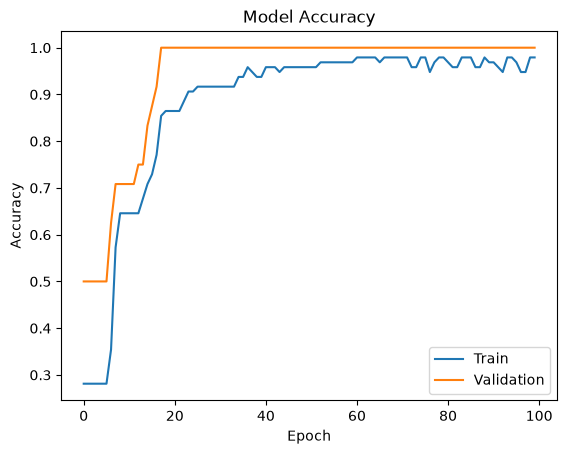

In [ ]:
loss, accuracy = model.evaluate(X_test,Y_test)
print(f"Loss: {loss},\n Accuracy: {accuracy}")
print(f"{history.history.keys()}")
plt.plot(history.history['Accuracy'])
plt.plot(history.history['val_Accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

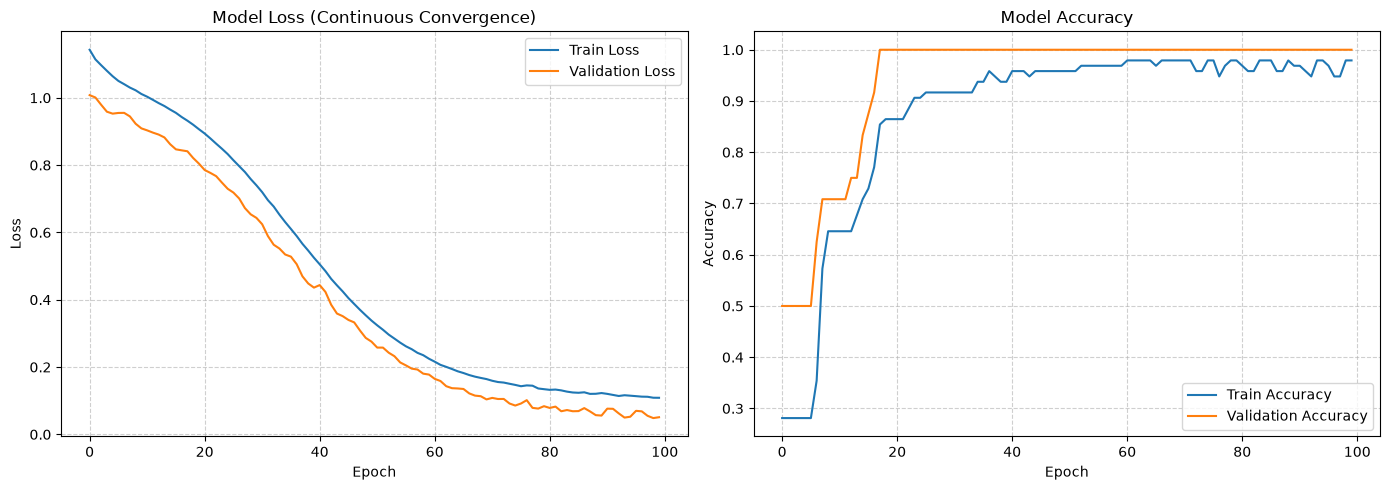

In [ ]:
import matplotlib.pyplot as plt

# Create a side-by-side plot of Loss and Accuracy to get a clearer picture
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss (Loss curves are continuous and show true convergence)
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Model Loss (Continuous Convergence)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Accuracy
ax2.plot(history.history['Accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_Accuracy'], label='Validation Accuracy')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

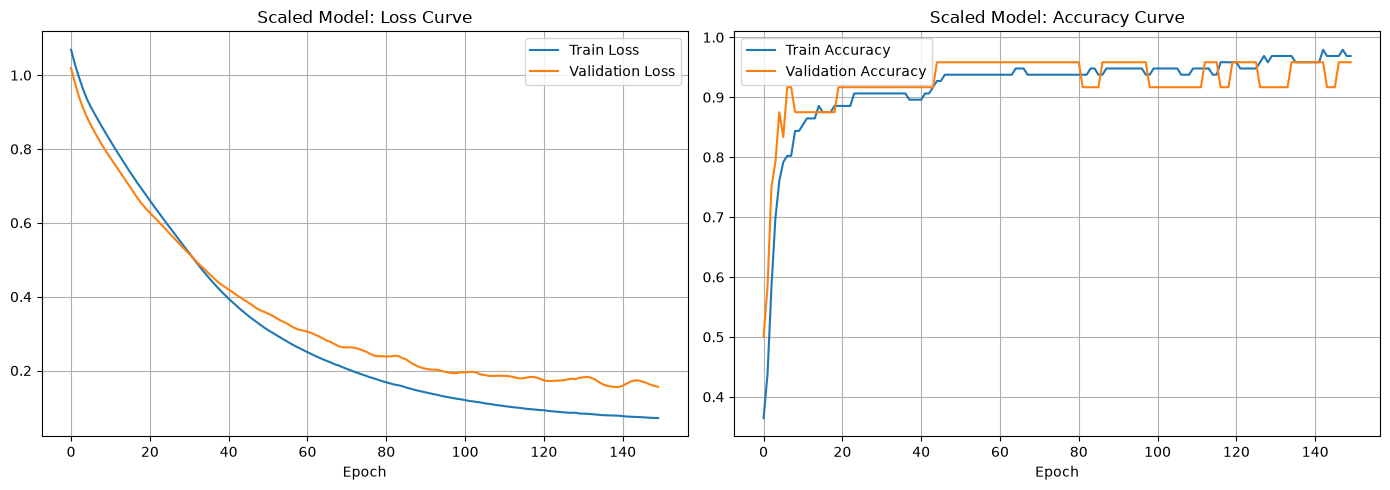

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Re-build and compile the model
stable_model = Sequential([
    Input(shape=(4,)),
    Dense(units=32, activation='relu'),
    Dense(units=16, activation='relu'),
    Dense(units=8, activation='relu'),
    Dense(units=3, activation='softmax')
])

stable_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for fewer epochs (e.g., 150 is more than enough for Iris)
stable_history = stable_model.fit(
    X_train_scaled, Y_train,
    epochs=150,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

# Plot the new, stabilized learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(stable_history.history['loss'], label='Train Loss')
ax1.plot(stable_history.history['val_loss'], label='Validation Loss')
ax1.set_title('Scaled Model: Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(stable_history.history['accuracy'], label='Train Accuracy')
ax2.plot(stable_history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Scaled Model: Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

test_sample = np.array([[5.4,3.4,1.5,0.4]])  # convert list → numpy
new_test_sample_scaled = scaler.transform(test_sample)  # Scale the new test sample
prediction = stable_model.predict(new_test_sample_scaled)

print("Predicted probabilities:", prediction)
predicted_class = prediction.argmax()

print(predicted_class)
predicted_label = le.inverse_transform([predicted_class])

print("Predicted class:", predicted_label[0])

/Users/macbookair/Desktop/ML/Envs/tf_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
Predicted probabilities: [[0.9852018  0.00759725 0.00720097]]
0
Predicted class: Iris-setosa


In [ ]:
import pickle

with open('iris_model_unscaled.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
# 1. Save your better, stabilized model using the native Keras format
stable_model.save('stable_iris_model.keras')

# 2. Save your fitted scaler so you can transform user inputs later
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("stable_model and scaler saved successfully!")

stable_model and scaler saved successfully!
